In [1]:
# Load some test data
import polars as pl
titanic = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/titanic.csv')
titanic.head()

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,str,i64,str,str,f64,i64,i64,str,f64,str,str
1,"""No""",3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S"""
2,"""Yes""",1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
3,"""Yes""",3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
4,"""Yes""",1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""
5,"""No""",3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S"""


In [9]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Let's treat Pclass as categorical
titanic = titanic.with_columns(pl.col('Pclass').cast(pl.Categorical).alias('Pclass_cat'))
# Encode our features and target as needed
features = ['Pclass_cat', 'Sex', 'Age', 'Embarked']
X = titanic.select(features).to_dummies(features, drop_first=True)
y = titanic.select(pl.col('Survived'))

# Split our data into training and test data, with 30% reserved for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# # Build the decision tree
clf = DecisionTreeClassifier(max_depth=15)

# # Train it
clf.fit(X_train, y_train)

# # Test it
clf.score(X_test, y_test)

# Note that this gives us an accuracy score, which may not be the best metric.
# See the SciKit-Learn docs for more ways to assess a model's performance, as
# well as methods for cross validation.

0.7611940298507462

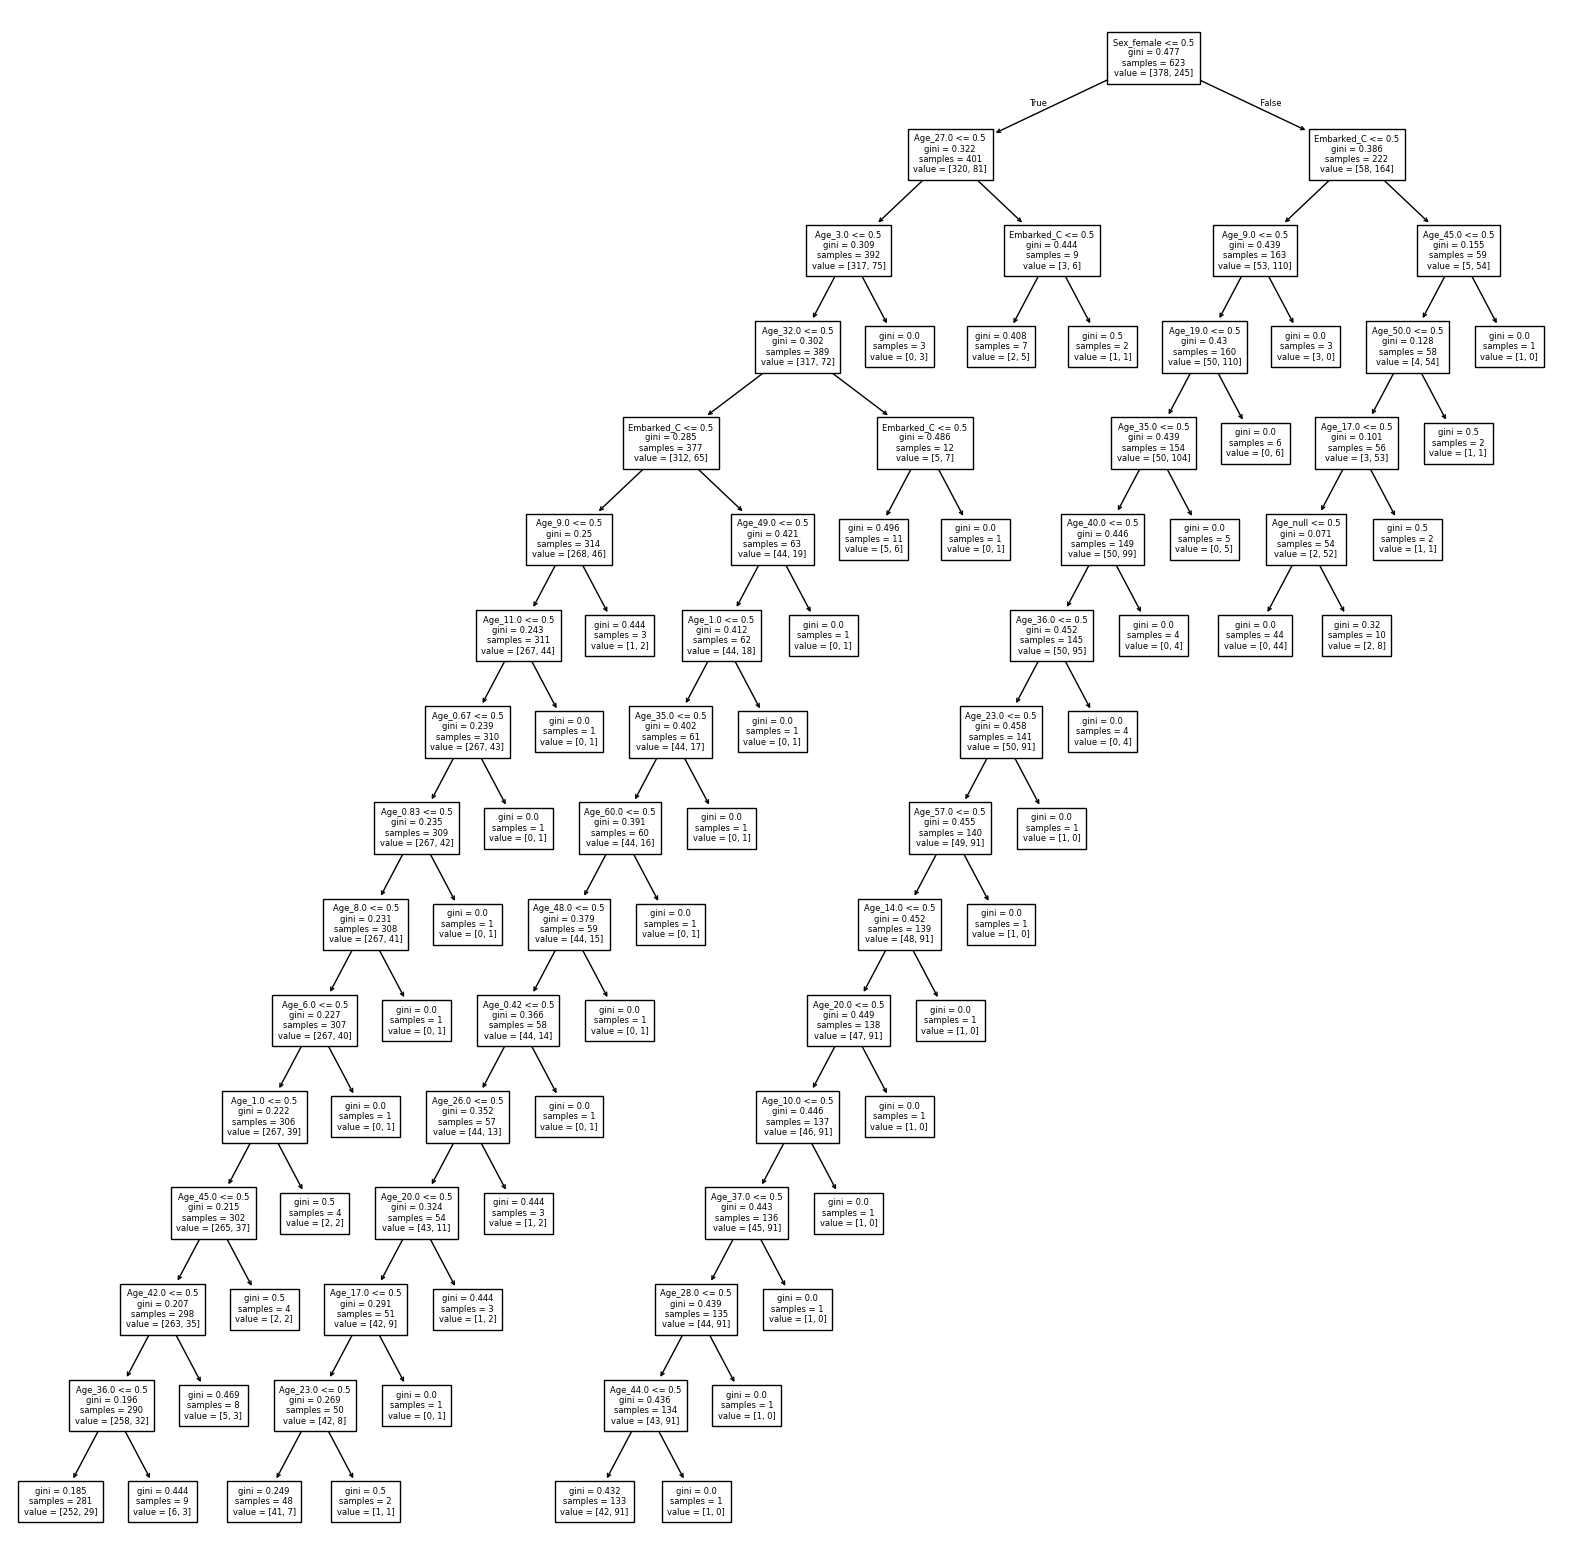

In [10]:
# Let's visualize the tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))
tree.plot_tree(clf, fontsize=6, feature_names=X.columns)
plt.show()